<a href="https://colab.research.google.com/github/navgaur/SP-QM_ML-2025/blob/main/QM_ML_update.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Summer Students project : June - August 2025**

## **Title : Estimating the energy of a Quantum Mechanical particle using Machine Learning**

## Authors : Ojas Jha, Manjeeta Nath
### Class : B.Sc. (H) Physics 2023-27
### Affiliation: Dept. of Physics, Dyal Singh College (University of Delhi)


### Mentor : Naveen Gaur

---

## 1. Imports libraries and global configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.linalg import eigvalsh_tridiagonal
from scipy.signal import find_peaks

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# numpy 2.x renamed trapz -> trapezoid; keep both working
_trapz = getattr(np, "trapezoid", None) or np.trapz

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=5, suppress=True)
#sns.set_theme(style="whitegrid")

plt.rcParams["figure.dpi"] = 110
# --- axis (spine) styling, applies to every figure ---
plt.rcParams["axes.linewidth"]      = 1.5      # seaborn default is 1.25
plt.rcParams["axes.edgecolor"]      = "0.3"  # seaborn default is '.8' light grey

# --- turn ticks ON (seaborn disables them) and put them on all four sides ---
plt.rcParams["xtick.bottom"]         = True
plt.rcParams["ytick.left"]           = True
plt.rcParams["xtick.top"]            = True
plt.rcParams["ytick.right"]          = True

# --- point ticks inward, the usual physics-journal convention ---
plt.rcParams["xtick.direction"]      = "in"
plt.rcParams["ytick.direction"]      = "in"

# --- major ticks ---
plt.rcParams["xtick.major.width"]    = 1.5
plt.rcParams["ytick.major.width"]    = 1.5
plt.rcParams["xtick.major.size"]     = 6
plt.rcParams["ytick.major.size"]     = 6
plt.rcParams["xtick.color"]          = "0.3"
plt.rcParams["ytick.color"]          = ".3"

# --- minor ticks (unlabelled subdivisions) ---
plt.rcParams["xtick.minor.visible"]  = True
plt.rcParams["ytick.minor.visible"]  = True
plt.rcParams["xtick.minor.width"]    = 1
plt.rcParams["ytick.minor.width"]    = 1
plt.rcParams["xtick.minor.size"]     = 3
plt.rcParams["ytick.minor.size"]     = 3

# --- keep the grid from competing with the heavier axes ---
plt.rcParams["grid.linewidth"]       = 0.6
plt.rcParams["grid.alpha"]           = 0.5

# --- font sizes ---
plt.rcParams["xtick.labelsize"]  = 9      # tick numbers (was 11)
plt.rcParams["ytick.labelsize"]  = 9
plt.rcParams["legend.fontsize"]  = 11     # legend text (was 11, but see note below)
plt.rcParams["axes.labelsize"]   = 12     # the "x" / "V(x)" labels
plt.rcParams["axes.titlesize"]   = 12     # subplot titles

# --- grid style ---
plt.rcParams["grid.linestyle"]   = "--"    # ':' dotted, '--' dashed, '-.' dash-dot
plt.rcParams["grid.linewidth"]   = 0.9
plt.rcParams["grid.color"]       = "0.6"
plt.rcParams["grid.alpha"]       = 0.7

# --- legend box ---
plt.rcParams["legend.frameon"]    = True
plt.rcParams["legend.framealpha"] = 0.9
plt.rcParams["legend.edgecolor"]  = "0.4"

print("configuration loaded")

configuration loaded


In [2]:
HBAR, MASS = 1.0, 1.0

N_GRID = 400              # grid points (same for every sample)
X_MAX  = 6.0              # domain is [-X_MAX, +X_MAX]
x_grid = np.linspace(-X_MAX, X_MAX, N_GRID)
dx     = x_grid[1] - x_grid[0]

V_CEIL   = 200.0          # finite wall height
N_STATES = 6              # number of eigenvalues used as regression targets

print(f"N_GRID = {N_GRID},  dx = {dx:.6f},  domain = [{-X_MAX}, {X_MAX}]")
print(f"targets: E_0 ... E_{N_STATES-1}   (natural units, hbar = m = 1)")

N_GRID = 400,  dx = 0.030075,  domain = [-6.0, 6.0]
targets: E_0 ... E_5   (natural units, hbar = m = 1)


## 2. The finite-difference solver

Discretising $-\dfrac{\hbar^2}{2m}\dfrac{d^2\psi}{dx^2} + V(x)\psi = E\psi$ with the
three-point second-derivative stencil gives a symmetric tridiagonal Hamiltonian

Kinetic energy matrix :
$
\hat{T} = -\frac{\hbar^2}{2m} \frac{d^2}{dx^2}
\quad \Rightarrow \quad
T = -\frac{\hbar^2}{2m \Delta x^2}
\begin{bmatrix}
-2 & 1 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & \cdots & 0 \\
0 & 0 & 1 & -2 & \cdots & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & 0 & \cdots & -2
\end{bmatrix}
$


$$H_{ii} = V_i + \frac{\hbar^2}{m\,\Delta x^2}, \qquad
  H_{i,i\pm1} = -\frac{\hbar^2}{2m\,\Delta x^2}$$

We use `eigvalsh_tridiagonal` with `select='i'` to compute **only** the lowest `N_STATES`
eigenvalues — considerably faster than forming the dense matrix and diagonalising it fully.

In [3]:
# Function to Solve Schrodinger Equation, it returns array of n_states eigenvalues

def solve_schrodinger(V, n_states=N_STATES, spacing=None):
  'Lowest n_states eigenvalues of H = T + V on the fixed grid.'
  h = dx if spacing is None else spacing
  coeff        = HBAR**2 / (2 * MASS * h**2)
  diagonal     = V + 2 * coeff
  off_diagonal = -coeff * np.ones(len(V) - 1)
  return eigvalsh_tridiagonal(diagonal, off_diagonal,
                            select='i', select_range=(0, n_states - 1))

### 2.1 Validating the solver against exact results

Before trusting *any* machine-learning result we must confirm the labels themselves are
correct. We check against the two analytically solvable cases:

$$E_n^{\text{box}} = \frac{n^2\pi^2\hbar^2}{2mL^2}\ (n=1,2,\dots), \qquad
  E_n^{\text{SHO}} = \left(n+\tfrac12\right)\hbar\sqrt{k/m}\ (n=0,1,\dots)$$

In [4]:
rows = []

a = 2.0                                            # infinite well, walls at +/- a  => L = 2a
V_box = np.where(np.abs(x_grid) < a, 0.0, 1e6)
E_box = solve_schrodinger(V_box, 4)
L_box = 2 * a
for n in range(1, 5):
  exact = n**2 * np.pi**2 * HBAR**2 / (2 * MASS * L_box**2)
  rows.append(["Infinite well", n, E_box[n-1], exact,
                 abs(E_box[n-1] - exact) / exact * 100])

k_spring = 1.0                                     # harmonic oscillator
V_sho = 0.5 * k_spring * x_grid**2
E_sho = solve_schrodinger(V_sho, 4)
for n in range(4):
  exact = (n + 0.5) * np.sqrt(k_spring / MASS) * HBAR
  rows.append(["Harmonic osc.", n, E_sho[n], exact,
                 abs(E_sho[n] - exact) / exact * 100])

df_val = pd.DataFrame(rows, columns=["System", "n", "Numerical", "Exact", "Error (%)"])
display(df_val.style.format({"Numerical": "{:.6f}", "Exact": "{:.6f}",
                             "Error (%)": "{:.4f}"}).hide(axis="index"))
print(f"\nmaximum discretisation error: {df_val['Error (%)'].max():.4f} %")

System,n,Numerical,Exact,Error (%)
Infinite well,1,0.308406,0.308425,0.0063
Infinite well,2,1.233451,1.233701,0.0203
Infinite well,3,2.774619,2.775826,0.0435
Infinite well,4,4.931050,4.934802,0.0760
Harmonic osc.,0,0.499972,0.500000,0.0057
Harmonic osc.,1,1.499859,1.500000,0.0094
Harmonic osc.,2,2.499632,2.500000,0.0147
Harmonic osc.,3,3.499293,3.500000,0.0202



maximum discretisation error: 0.0760 %


**Numerical Errors:** Errors below ~0.1% confirm the grid is fine enough. The error growing with $n$ is expected:
higher states oscillate faster and are resolved less well by a fixed grid. This is precisely
why we keep only the lowest few eigenvalues as targets — the high-lying states of a
finite box are dominated by the artificial boundary, not by the physics of the well.

The numerical error in energy estimation also goes as $E \sim n^2$. This happens because of the Taylor series expansion of trignometric function where higher order terms are neglected.


## 3. The problem we were having earlier

Before building the corrected dataset, let us reproduce the fault explicitly. This cell runs the *original* generators and counts how many genuinely distinct potentials they produce.

As one can see from below section that there are only 3 unique potential rows which is the problem with earlier version of the program.

In [5]:
def orig_infinite_well(N=1000, L=1.0):
  V = np.zeros(N); V[0] = V[-1] = 1e10
  return V, L / N

def orig_finite_well(N=1000, L=4.0):
  V = np.full(N, 20.0); V[int(0.02*N):int(0.98*N)] = 0.0
  return V, L / N

def orig_harmonic(N=1000, x_max=5.0):
  xx = np.linspace(-x_max, x_max, N)
  return 0.5 * xx**2, xx[1] - xx[0]

orig_rng = np.random.default_rng(0)   # Initializing random number generator constructor
gens_orig = [orig_infinite_well, orig_finite_well, orig_harmonic]

Xo, Yo = [], []
for _ in range(600):
  V, spacing = gens_orig[orig_rng.integers(3)]()
  Xo.append(V); Yo.append(solve_schrodinger(V, N_STATES, spacing=spacing))
Xo, Yo = np.array(Xo), np.array(Yo)

print(f"samples generated      : {len(Xo)}")
print(f"UNIQUE potential rows  : {len(np.unique(Xo, axis=0))}   <-- Problem")

Xo_tr, Xo_te, Yo_tr, Yo_te = train_test_split(Xo, Yo, test_size=0.2, random_state=1)
sc_o = StandardScaler()
pred_o = LinearRegression().fit(sc_o.fit_transform(Xo_tr), Yo_tr).predict(sc_o.transform(Xo_te))

print(f"\nMAE = {mean_absolute_error(Yo_te, pred_o):.6f}")
print(f"R^2 = {r2_score(Yo_te, pred_o):.6f}   <-- the illusory 'perfect' score")

overlap = len({r.tobytes() for r in Xo_tr} & {r.tobytes() for r in Xo_te})
print(f"\ndistinct potentials appearing in BOTH train and test: {overlap}")

samples generated      : 600
UNIQUE potential rows  : 3   <-- Problem

MAE = 0.000000
R^2 = 1.000000   <-- the illusory 'perfect' score

distinct potentials appearing in BOTH train and test: 3


Three unique inputs, all three present in both splits, and a perfect score. The model memorised three numbers.

**This is the result (in above block) that had to be discarded.**

## 4. The corrected dataset

Three families, each with genuinely randomised *shape* parameters, all evaluated on the
shared grid:

| Family | Form | Randomised parameters |
|---|---|---|
| Square well | $V=0$ for $\lvert x\rvert<a$, else $V_0$ | half-width $a$, depth $V_0$ |
| Harmonic | $V=\tfrac12 k x^2$ | spring constant $k$ |
| Gaussian well | $V=d\left[1-e^{-x^2/2\sigma^2}\right]$ | depth $d$, width $\sigma$ |

Each generator accepts an optional centre `x0`; we keep `x0 = 0` for the main study and revisit it in the translation stress test of Section 9.

In [6]:
# This section solves SE by randomizing potentials and even invoking potentials randomly
# The function "build_dataset" returns the array of Potential and Eigenvalues

def make_square_well(rng, x0=0.0):
  a  = rng.uniform(0.8, 3.5)
  V0 = rng.uniform(20.0, V_CEIL)
  V  = np.where(np.abs(x_grid - x0) < a, 0.0, V0)
  return V, {"family": "square_well", "a": a, "V0": V0, "x0": x0}

def make_harmonic(rng, x0=0.0):
  k = rng.uniform(0.2, 4.0)
  V = np.minimum(0.5 * k * (x_grid - x0)**2, V_CEIL)
  return V, {"family": "harmonic", "k": k, "x0": x0}

def make_gaussian_well(rng, x0=0.0):
  d     = rng.uniform(20.0, 120.0)
  sigma = rng.uniform(1.0, 3.0)
  V     = d * (1.0 - np.exp(-(x_grid - x0)**2 / (2 * sigma**2)))
  return V, {"family": "gaussian_well", "depth": d, "sigma": sigma, "x0": x0}

FAMILIES = [make_square_well, make_harmonic, make_gaussian_well]

def build_dataset(n_samples, rng, jitter=False):
  X = np.zeros((n_samples, N_GRID))
  Y = np.zeros((n_samples, N_STATES))
  meta = []
  for i in range(n_samples):
    x0 = rng.uniform(-1.5, 1.5) if jitter else 0.0
    V, info = FAMILIES[rng.integers(len(FAMILIES))](rng, x0=x0)
    X[i], Y[i] = V, solve_schrodinger(V)
    meta.append(info)
  return X, Y, meta

This draws 5 sample (for each) potentials and check if they are random.

$d_{min}$ is the sum of the seperations (summed over all the grid points) of the closest potentials.

$d_{min} = \sqrt{\sum_{j} \triangle V_j^2}$

This quantity is grid dependent but is indicative that the potentials are sufficiently seperate for further processing.

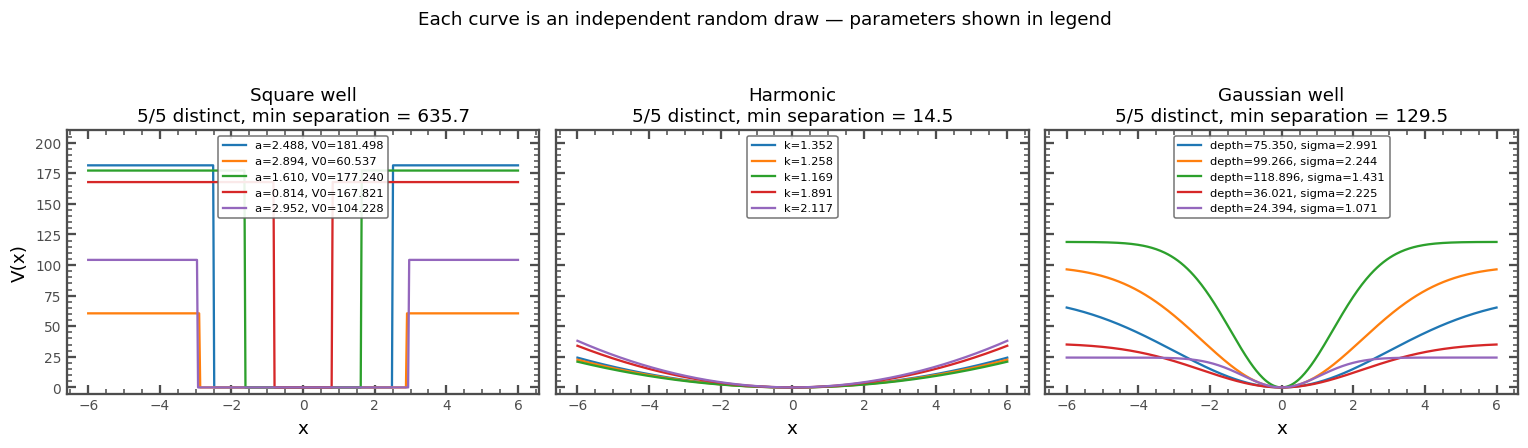

,family,draw,a,V0,k,depth,sigma
0,square_well,0,2.487758,181.498484,NaN,NaN,NaN
1,square_well,1,2.894351,60.537294,NaN,NaN,NaN
2,square_well,2,1.610449,177.239620,NaN,NaN,NaN
3,square_well,3,0.814216,167.821115,NaN,NaN,NaN
4,square_well,4,2.952087,104.228292,NaN,NaN,NaN
5,harmonic,0,NaN,NaN,1.351523,NaN,NaN
6,harmonic,1,NaN,NaN,1.258017,NaN,NaN
7,harmonic,2,NaN,NaN,1.168504,NaN,NaN
8,harmonic,3,NaN,NaN,1.891290,NaN,NaN
9,harmonic,4,NaN,NaN,2.117283,NaN,NaN


Spread of the drawn parameters:
  a     : min=   0.814  max=   2.952  spread=   2.138  all distinct=True
  V0    : min=  60.537  max= 181.498  spread= 120.961  all distinct=True
  k     : min=   1.169  max=   2.117  spread=   0.949  all distinct=True
  depth : min=  24.394  max= 118.896  spread=  94.502  all distinct=True
  sigma : min=   1.071  max=   2.991  spread=   1.920  all distinct=True


In [7]:
N_DRAWS = 5
demo_rng = np.random.default_rng(7)      # fixed seed -> reproducible figure

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
records = []

for ax, gen, name in zip(axes, FAMILIES, ["Square well", "Harmonic", "Gaussian well"]):
  drawn = []
  for d in range(N_DRAWS):
    V, info = gen(demo_rng)                     # KEEP the parameters
    drawn.append(V)
    label = ", ".join(f"{k}={v:.3f}" for k, v in info.items()
                      if k not in ("family", "x0"))
    ax.plot(x_grid, V, lw=1.5, label=label)
    records.append({"family": info["family"], "draw": d,
                    **{k: v for k, v in info.items() if k not in ("family", "x0")}})

  drawn = np.array(drawn)
  n_unique = len(np.unique(drawn, axis=0))
  # Minimum seperation between the potentials
  dmin = min(np.linalg.norm(drawn[p] - drawn[q])
            for p in range(N_DRAWS) for q in range(p + 1, N_DRAWS))
  ax.set_title(f"{name}\n{n_unique}/{N_DRAWS} distinct, min separation = {dmin:.1f}")
  ax.set_xlabel("x"); ax.set_ylim(-5, 210)
  ax.legend(fontsize=7.5, loc="upper center")

axes[0].set_ylabel("V(x)")
plt.suptitle("Each curve is an independent random draw — parameters shown in legend", y=1.06)
plt.tight_layout()
plt.show()

df_draws = pd.DataFrame(records)
display(df_draws)

print("Spread of the drawn parameters:")
for col in ["a", "V0", "k", "depth", "sigma"]:
  if col in df_draws:
    v = df_draws[col].dropna().values
    print(f"  {col:6s}: min={v.min():8.3f}  max={v.max():8.3f}  "
            f"spread={v.max()-v.min():8.3f}  all distinct={len(np.unique(v))==len(v)}")

In [8]:
N_SAMPLES = 1500
X, Y, META = build_dataset(N_SAMPLES, rng, jitter=False)
family = np.array([m["family"] for m in META])

print(f"X shape {X.shape},  Y shape {Y.shape}")
print(f"UNIQUE potential rows: {len(np.unique(X, axis=0))} of {len(X)}\n")

summary = []
for f in ["square_well", "harmonic", "gaussian_well"]:
  idx = family == f
  summary.append([f, int(idx.sum()), Y[idx, 0].min(), Y[idx, 0].max(),
                    Y[idx, -1].min(), Y[idx, -1].max()])

display(pd.DataFrame(summary, columns=["family", "n", "E0 min", "E0 max",
                                      f"E{N_STATES-1} min", f"E{N_STATES-1} max"]
                     ).style.format({c: "{:.4f}" for c in
                     ["E0 min", "E0 max", f"E{N_STATES-1} min", f"E{N_STATES-1} max"]}
                     ).hide(axis="index"))

X shape (1500, 400),  Y shape (1500, 6)
UNIQUE potential rows: 1500 of 1500



family,n,E0 min,E0 max,E5 min,E5 max
square_well,484,0.0938,1.6306,3.3713,57.7656
harmonic,508,0.2312,0.9993,2.5539,10.9870
gaussian_well,508,0.7621,5.1866,7.8289,52.3280


 **Note** : For the shallower square and Gaussian wells, not all six computed eigenvalues are true *bound* states — those lying above the well depth $V_0$ are box states set by the artificial domain walls at $\pm 6$. They are still perfectly well-defined eigenvalues of the discretised Hamiltonian, which is what we are learning to predict, but they should not be interpreted as bound states of the isolated well.

## 5. Train/test split, scaling, and conditioning diagnostics

We are also ensuring that all the data sets (potentials) are independent/randomized.

In [9]:
X_train, X_test, Y_train, Y_test, fam_train, fam_test = train_test_split(
    X, Y, family, test_size=0.2, random_state=SEED, stratify=family)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on TRAIN only
X_test_s  = scaler.transform(X_test)        # never re-fit on test

train_rows = {r.tobytes() for r in X_train}
test_rows  = {r.tobytes() for r in X_test}
print(f"train {X_train.shape},  test {X_test.shape}")
print(f"potentials shared between train and test: {len(train_rows & test_rows)}  (must be 0)")

train (1200, 400),  test (300, 400)
potentials shared between train and test: 0  (must be 0)


### 5.1 Why Ordinary Least Squares (OLS) is the wrong tool here


OLS mandate minimization of $||\bf{ X \beta - y}||^2||$ by evaluating the first derivative and equating it to zero:

$\bf{X^T X \beta = X^T y}$

To solve for $\beta$ one has to invert $\bf{X^T X}$ which can only be done if the matrix can be inverted.


In our case $\bf{X}$ is $(1200,400)$ and hence $\bf{X^T X}$ should be $(400,400)$ and hence $\bf{X^T X}$ is invertible if Rank($\bf{X^T X}$) = 400 which means all the rows/columns of the matrix should be independent.  The actual rank of $\bf{X}$ is 101 (depends on random number but in general it is much smaller compared to 400). This means all the rows/columns of the matrix are not independent and hence matrix is not invertible.

Typically the three potentials that we have used have ranks of the matrices in following order

Harmonic  <  Gaussian <  Square Well

This is expected as the shapes of Harmonic and Gaussian are dictated by some parameters and hence likely that columns are not linearly independent.

---
The section below actually checks if the matrix ($X^T X$) is singular as if it is singular then one can not use OLS for analysis.

This check is done by usage of *linalg.svd* which does singular value decomposition. If the matrix is not a square matrix then essentially it evaluates the eigenvalues of $A^T A$.

The result is shown in form of a plot of number of eigenvalues and their actual values. One can see that nearly 100 eigenvalues are non-zero
indicating that nearly 300 (out of 400) are zero making this matrix to be a singular matrix and hence OLS can not be used.


In below graph the index right (after $\sim 101$) the potentials do not vary. The eigenvalues of ($X^T X$) after the rank (101) are nearly zero which means no variation in potential.

design matrix        : (1200, 400)
numerical rank       : 101  (of 400 columns)
largest  singular val: 549.6
smallest singular val: 1.484e-31
condition number     : 3.704e+33


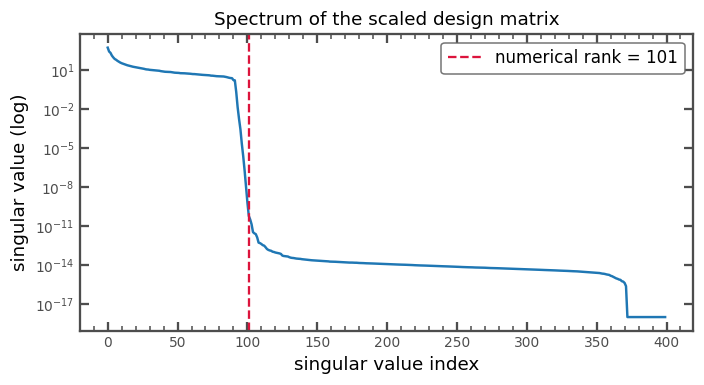

In [10]:
sv   = np.linalg.svd(X_train_s, compute_uv=False)
rank = np.linalg.matrix_rank(X_train_s)

print(f"design matrix        : {X_train_s.shape}")
print(f"numerical rank       : {rank}  (of {X_train_s.shape[1]} columns)")
print(f"largest  singular val: {sv[0]:.4g}")
print(f"smallest singular val: {sv[-1]:.4g}")
print(f"condition number     : {sv[0] / max(sv[-1], 1e-300):.4g}")

plt.figure(figsize=(6.5, 3.6))
plt.semilogy(np.maximum(sv, 1e-18), lw=1.6)
plt.axvline(rank, color="crimson", ls="--", label=f"numerical rank = {rank}")
plt.xlabel("singular value index"); plt.ylabel("singular value (log)")
plt.title("Spectrum of the scaled design matrix")
plt.legend(); plt.tight_layout(); plt.show()

The rank is a small fraction of the number of columns and the condition number is astronomically large. The reason is physical: in a square well every grid point inside the well is exactly $0$ and every point outside is exactly $V_0$, so hundreds of columns are *identical*. $\mathbf{X}^\top\mathbf{X}$ is therefore singular, OLS is not uniquely defined,
and its coefficients can explode.


###**Ridge regression**
Solves
$(\mathbf{X}^\top\mathbf{X} + \alpha\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$, is well-defined for any $\alpha>0$.

Ridge is a one-term modification of OLS to eliminate the singular terms. This is done to add a term on the size of coefficients.

OLS (minimizes $\beta$) : $||X \beta - y||^2$

Ride (minimizes $\beta$) : $||X \beta - y||^2 + \alpha ||\beta||^2$

So the solution changes to
$\mathbf{\beta = (X^T X + \alpha I)^{-1} X^T y}$

So there is an extra term of $\mathbf{\alpha I}$. This extra term shifts the zero eigenvalues and hence resolves the problem.

## 6. Model comparison on raw grid features

In [11]:
ridge_cv = RidgeCV(alphas=np.logspace(-3, 4, 40)).fit(X_train_s, Y_train)
print(f"RidgeCV selected alpha = {ridge_cv.alpha_:.4g}")

models = {
    "OLS (LinearRegression)": LinearRegression(),
    f"Ridge (alpha={ridge_cv.alpha_:.3g})": Ridge(alpha=ridge_cv.alpha_),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1),
}

rows, preds = [], {}
for name, mdl in models.items():
    mdl.fit(X_train_s, Y_train)
    P = mdl.predict(X_test_s)
    preds[name] = P
    coef_norm = np.abs(mdl.coef_).max() if hasattr(mdl, "coef_") else np.nan
    rows.append([name, mean_absolute_error(Y_test, P),
                 np.sqrt(mean_squared_error(Y_test, P)),
                 r2_score(Y_test, P), r2_score(Y_test[:, 0], P[:, 0]), coef_norm])

df_models = pd.DataFrame(rows, columns=["model", "MAE", "RMSE", "R2 (all states)",
                                        "R2 (E0)", "max |coef|"])
display(df_models.style.format({"MAE": "{:.4g}", "RMSE": "{:.4g}",
                                "R2 (all states)": "{:.5g}", "R2 (E0)": "{:.5g}",
                                "max |coef|": "{:.3g}"}).hide(axis="index"))

RidgeCV selected alpha = 5.878


model,MAE,RMSE,R2 (all states),R2 (E0),max |coef|
OLS (LinearRegression),1.024,2.261,0.92045,0.96119,1.39e+07
Ridge (alpha=5.88),1.037,2.211,0.92283,0.96057,1.91
RandomForest,0.06064,0.2481,0.99869,0.998,nan


Note the `max |coef|` column: it is the quantitative signature of ill-conditioning. Ridge
keeps the coefficients bounded; OLS on this collinear design is numerically unstable and its
weights can reach absurd magnitudes, at which point predictions become meaningless.

**Whatever the numbers above, the honest headline is that $R^2$ is no longer $1$** — and it
*should not be*. The map from $V$ to $E$ is genuinely non-linear:
$E_n^{\text{SHO}} \propto \sqrt{k}$ while $V \propto k$, and $E \propto 1/L^2$ for a well of
width $L$. A model linear in $V$ cannot reproduce a square root exactly, so a ceiling below
$R^2=1$ is the physically correct answer.

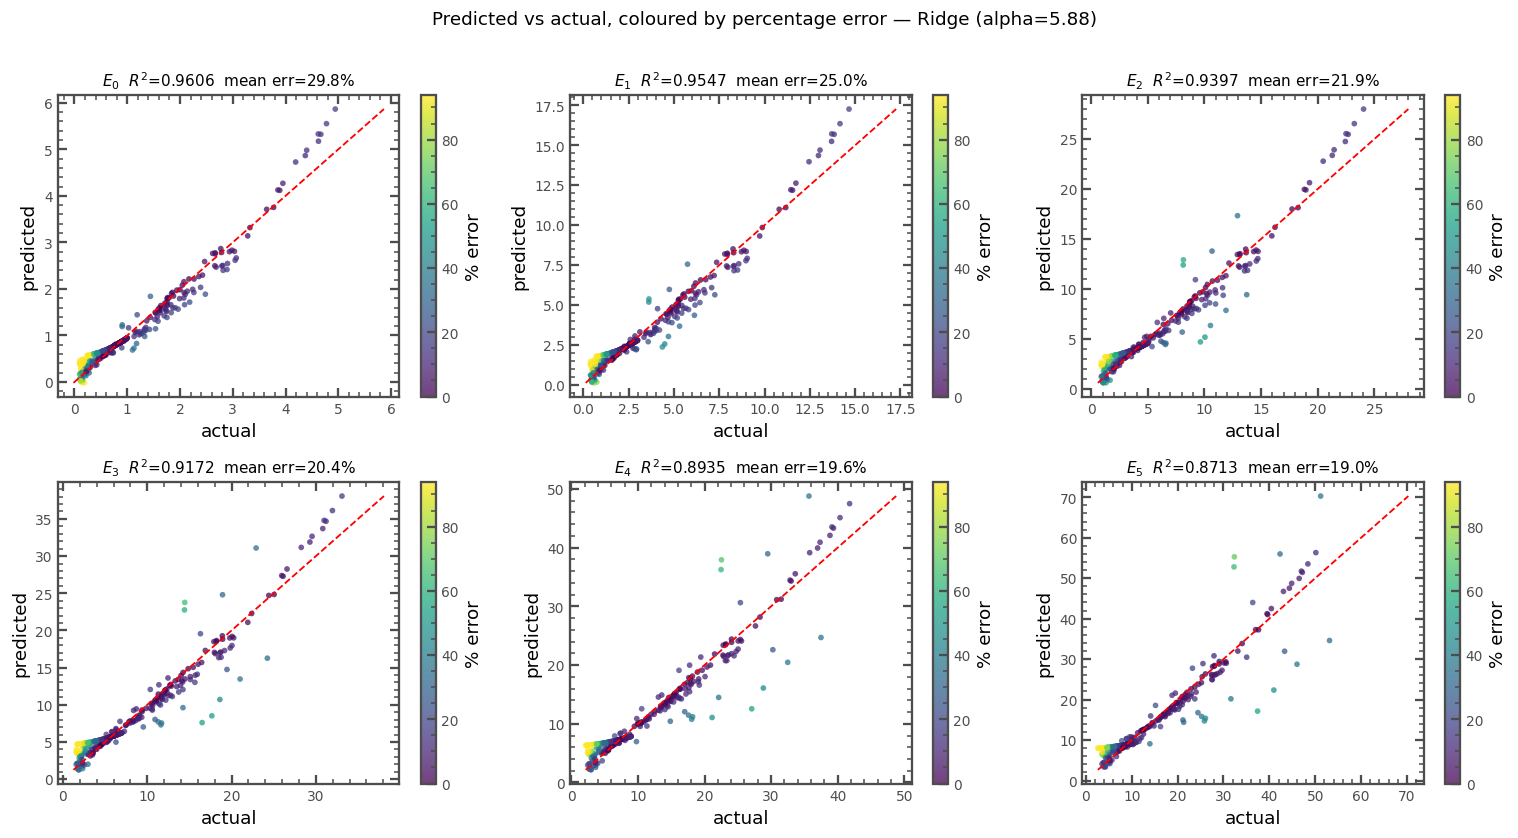

In [12]:
best = f"Ridge (alpha={ridge_cv.alpha_:.3g})"
P_ridge = preds[best]

pct_err = np.abs(P_ridge - Y_test) / np.abs(Y_test) * 100

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for n, ax in enumerate(axes.ravel()):
  sc_ = ax.scatter(Y_test[:, n], P_ridge[:, n], c=pct_err[:, n], cmap="viridis",
                     s=14, alpha=0.75, edgecolors="none",
                     vmin=0, vmax=np.percentile(pct_err, 95))
#  ax.scatter(Y_test[:, n], P_ridge[:, n], s=12, alpha=0.5, edgecolors="none")
  lo = min(Y_test[:, n].min(), P_ridge[:, n].min())
  hi = max(Y_test[:, n].max(), P_ridge[:, n].max())
  ax.plot([lo, hi], [lo, hi], "r--", lw=1.2)
#  ax.set_title(f"$E_{n}$   $R^2$ = {r2_score(Y_test[:, n], P_ridge[:, n]):.4f}")
  ax.set_title(f"$E_{n}$  $R^2$={r2_score(Y_test[:,n], P_ridge[:,n]):.4f}  "
                 f"mean err={pct_err[:,n].mean():.1f}%", fontsize=10)
  ax.set_xlabel("actual"); ax.set_ylabel("predicted")
  plt.colorbar(sc_, ax=ax, label="% error")
#plt.suptitle(f"Predicted vs actual — {best}", y=1.01)
plt.suptitle(f"Predicted vs actual, coloured by percentage error — {best}", y=1.01)
plt.tight_layout(); plt.show()

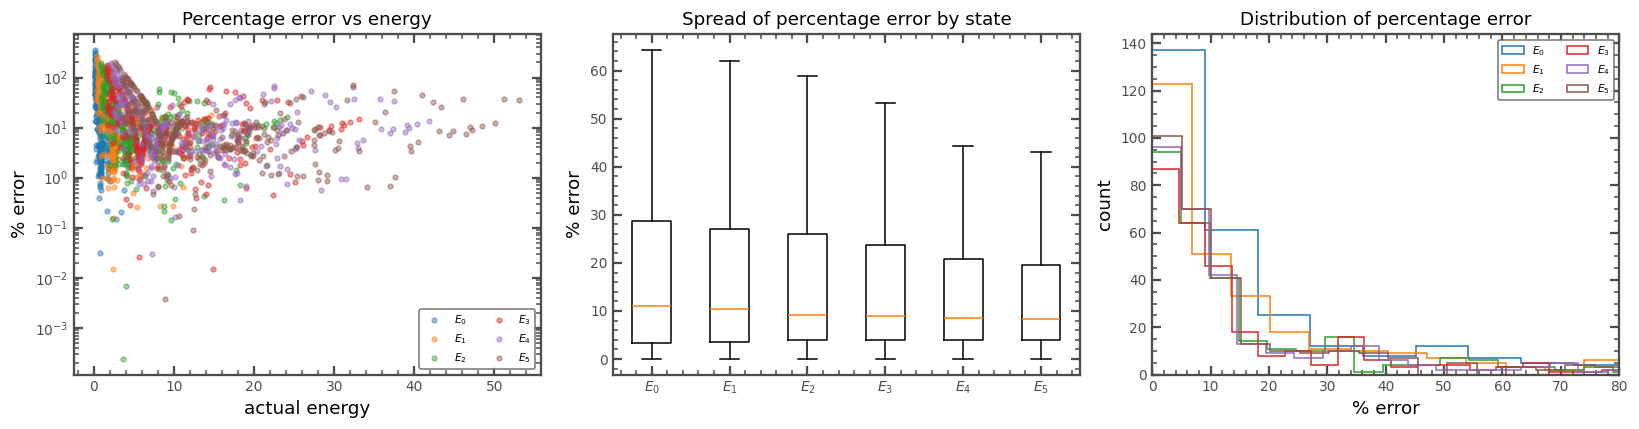

               E0      E1      E2      E3      E4      E5  
mean   % :    29.79   25.03   21.87   20.41   19.64   19.01
median % :    11.11   10.36    9.16    8.96    8.64    8.26
90th   % :    77.37   66.94   57.88   54.14   50.92   46.08


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for n in range(N_STATES):
    axes[0].scatter(Y_test[:, n], pct_err[:, n], s=10, alpha=0.45, label=f"$E_{n}$")
axes[0].set_xlabel("actual energy"); axes[0].set_ylabel("% error")
axes[0].set_yscale("log"); axes[0].set_title("Percentage error vs energy")
axes[0].legend(fontsize=7, ncol=2)

axes[1].boxplot([pct_err[:, n] for n in range(N_STATES)],
                tick_labels=[f"$E_{n}$" for n in range(N_STATES)], showfliers=False)
axes[1].set_ylabel("% error"); axes[1].set_title("Spread of percentage error by state")

for n in range(N_STATES):
    axes[2].hist(pct_err[:, n], bins=40, histtype="step", lw=1.5, label=f"$E_{n}$")
axes[2].set_xlabel("% error"); axes[2].set_ylabel("count"); axes[2].set_xlim(0, 80)
axes[2].set_title("Distribution of percentage error"); axes[2].legend(fontsize=7, ncol=2)

plt.tight_layout(); plt.show()

print("           " + "".join(f"    E{n}  " for n in range(N_STATES)))
print("mean   % : " + "".join(f"{v:8.2f}" for v in pct_err.mean(0)))
print("median % : " + "".join(f"{v:8.2f}" for v in np.median(pct_err, 0)))
print("90th   % : " + "".join(f"{v:8.2f}" for v in np.percentile(pct_err, 90, axis=0)))

## 7. Physics-informed features

Feeding 400 raw grid values to a linear model is wasteful: it must learn from scratch that
the answer depends on the *shape* of the well. Instead we hand it a small set of
physically meaningful, translation-invariant descriptors — including
$1/\text{width}^2$ and $\sqrt{\text{curvature}}$, because we know from the analytic
solutions that $E \propto 1/L^2$ and $E \propto \sqrt{k}$.

Supplying the right basis functions is the machine-learning expression of physical insight.

In [14]:
FEATURE_NAMES = ["V_min", "V_max", "V_mean", "V_std", "integral_V", "well_width",
                 "1/width^2", "curvature", "sqrt(curvature)", "roughness",
                 "asymmetry", "n_minima", "V_centre"]

def physics_features(V):
    V_min, V_max = V.min(), V.max()
    threshold = V_min + 0.1 * (V_max - V_min)
    width     = np.sum(V < threshold) * dx           # classical turning-point width
    grad      = np.gradient(V, dx)

    i0 = int(np.argmin(V))                           # curvature at the minimum
    lo, hi = max(i0 - 20, 0), min(i0 + 21, len(V))
    curv = 2 * np.polyfit(x_grid[lo:hi], V[lo:hi], 2)[0] if hi - lo > 3 else 0.0
    curv = max(curv, 0.0)

    return [V_min, V_max, V.mean(), V.std(), _trapz(V, x_grid), width,
            1.0 / max(width, 1e-6)**2, curv, np.sqrt(curv), np.std(grad),
            np.sum(np.abs(V - V[::-1])) * dx, len(find_peaks(-V)[0]), V[len(V)//2]]

F_train = np.array([physics_features(v) for v in X_train])
F_test  = np.array([physics_features(v) for v in X_test])

scaler_f  = StandardScaler()
F_train_s = scaler_f.fit_transform(F_train)
F_test_s  = scaler_f.transform(F_test)
print(f"{F_train.shape[1]} physics features vs {X_train.shape[1]} raw grid points")

13 physics features vs 400 raw grid points


In [15]:
rows = []
feat_models = {
    "OLS (physics feats)": LinearRegression(),
    "Ridge (physics feats)": RidgeCV(alphas=np.logspace(-3, 4, 40)),
    "RandomForest (physics feats)": RandomForestRegressor(n_estimators=200,
                                                          random_state=SEED, n_jobs=-1),
}
for name, mdl in feat_models.items():
    mdl.fit(F_train_s, Y_train)
    P = mdl.predict(F_test_s)
    preds[name] = P
    rows.append([name, mean_absolute_error(Y_test, P),
                 np.sqrt(mean_squared_error(Y_test, P)),
                 r2_score(Y_test, P), r2_score(Y_test[:, 0], P[:, 0])])
    if name.startswith("OLS"):
        model_phys, P_phys = mdl, P

df_feat = pd.concat([df_models[["model", "MAE", "RMSE", "R2 (all states)", "R2 (E0)"]],
                     pd.DataFrame(rows, columns=["model", "MAE", "RMSE",
                                                 "R2 (all states)", "R2 (E0)"])])
display(df_feat.style.format({"MAE": "{:.4g}", "RMSE": "{:.4g}",
                              "R2 (all states)": "{:.5g}",
                              "R2 (E0)": "{:.5g}"}).hide(axis="index"))

model,MAE,RMSE,R2 (all states),R2 (E0)
OLS (LinearRegression),1.024,2.261,0.92045,0.96119
Ridge (alpha=5.88),1.037,2.211,0.92283,0.96057
RandomForest,0.06064,0.2481,0.99869,0.998
OLS (physics feats),0.5873,1.465,0.97251,0.99718
Ridge (physics feats),0.5891,1.465,0.97246,0.99715
RandomForest (physics feats),0.08037,0.358,0.99819,0.9995


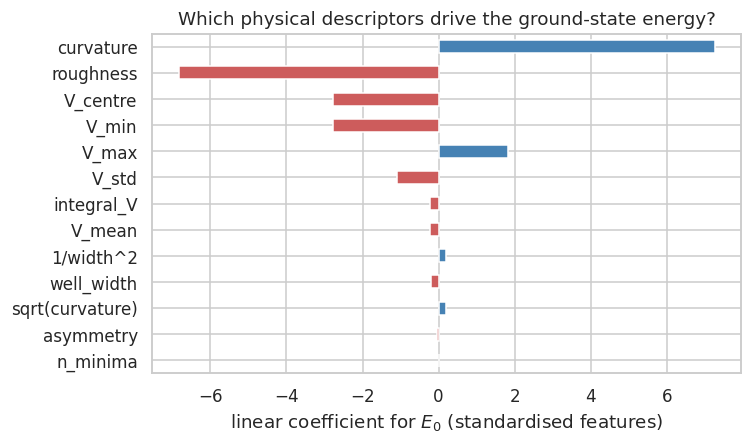

In [ ]:
coef_E0 = pd.Series(model_phys.coef_[0], index=FEATURE_NAMES).sort_values(key=np.abs)
plt.figure(figsize=(7, 4.2))
coef_E0.plot(kind="barh", color=np.where(coef_E0 > 0, "steelblue", "indianred"))
plt.xlabel("linear coefficient for $E_0$ (standardised features)")
plt.title("Which physical descriptors drive the ground-state energy?")
plt.tight_layout(); plt.show()

## 8. Error analysis

family,n,R2 (ridge/grid),MAE (ridge/grid),R2 (OLS/physics),MAE (OLS/physics)
square_well,97,0.7398,1.5353,0.8953,1.1270
harmonic,101,0.4370,0.7507,0.9870,0.1226
gaussian_well,102,0.9444,0.8478,0.9886,0.5341


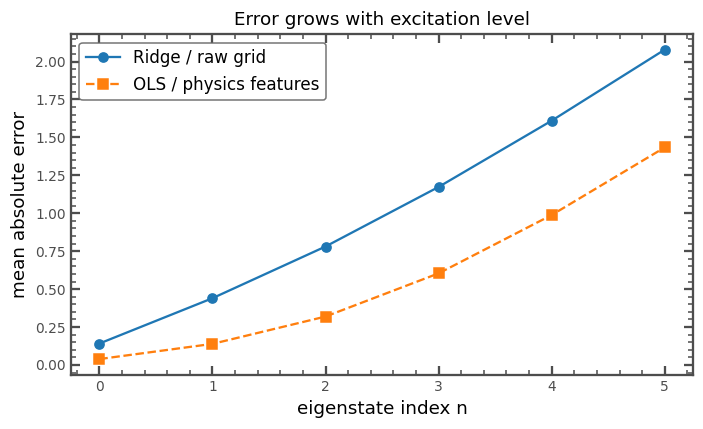

In [16]:
rows = []
for f in ["square_well", "harmonic", "gaussian_well"]:
    m = fam_test == f
    rows.append([f, int(m.sum()),
                 r2_score(Y_test[m], P_ridge[m]), mean_absolute_error(Y_test[m], P_ridge[m]),
                 r2_score(Y_test[m], P_phys[m]),  mean_absolute_error(Y_test[m], P_phys[m])])
display(pd.DataFrame(rows, columns=["family", "n", "R2 (ridge/grid)", "MAE (ridge/grid)",
                                    "R2 (OLS/physics)", "MAE (OLS/physics)"]
                     ).style.format({c: "{:.4f}" for c in
                     ["R2 (ridge/grid)", "MAE (ridge/grid)",
                      "R2 (OLS/physics)", "MAE (OLS/physics)"]}).hide(axis="index"))

mae_state_grid = [mean_absolute_error(Y_test[:, n], P_ridge[:, n]) for n in range(N_STATES)]
mae_state_phys = [mean_absolute_error(Y_test[:, n], P_phys[:, n])  for n in range(N_STATES)]

plt.figure(figsize=(6.5, 4))
plt.plot(range(N_STATES), mae_state_grid, "o-", label="Ridge / raw grid")
plt.plot(range(N_STATES), mae_state_phys, "s--", label="OLS / physics features")
plt.xlabel("eigenstate index n"); plt.ylabel("mean absolute error")
plt.title("Error grows with excitation level")
plt.legend(); plt.tight_layout(); plt.show()

Error increases with $n$ for two compounding reasons: higher eigenvalues are numerically
larger (so the same *relative* error is a bigger absolute one), and higher states oscillate
faster and are resolved less accurately on a fixed grid.

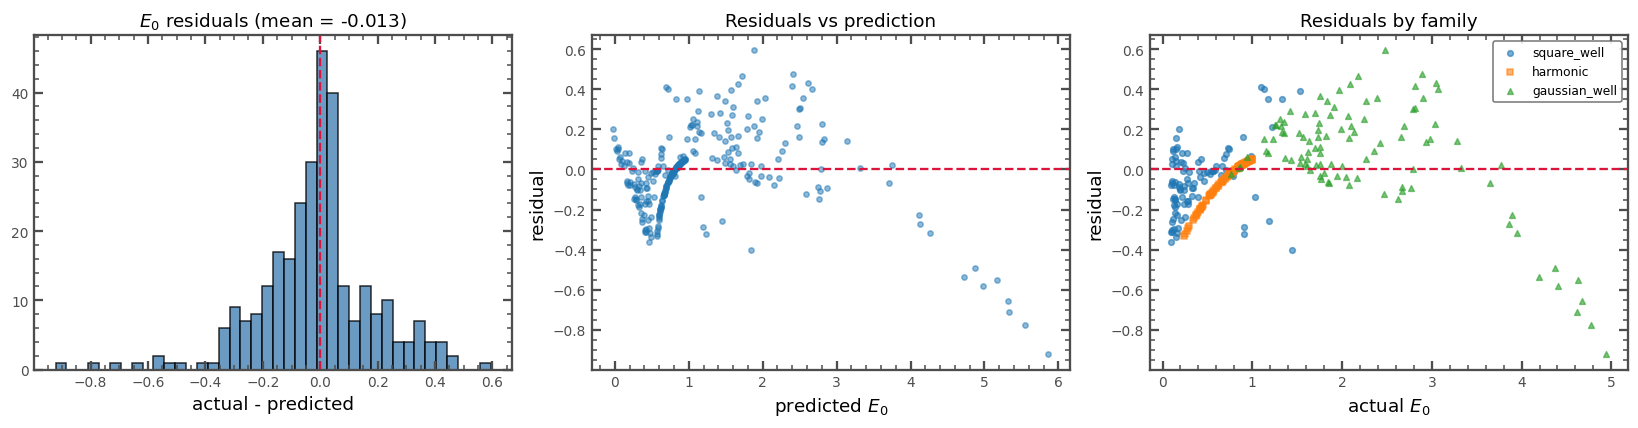

In [17]:
residuals = Y_test - P_ridge

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(residuals[:, 0], bins=40, color="steelblue", edgecolor="k", alpha=0.8)
axes[0].axvline(0, color="crimson", ls="--")
axes[0].set_title(f"$E_0$ residuals (mean = {residuals[:,0].mean():.3f})")
axes[0].set_xlabel("actual - predicted")

axes[1].scatter(P_ridge[:, 0], residuals[:, 0], s=12, alpha=0.5)
axes[1].axhline(0, color="crimson", ls="--")
axes[1].set_xlabel("predicted $E_0$"); axes[1].set_ylabel("residual")
axes[1].set_title("Residuals vs prediction")

for f, mk in zip(["square_well", "harmonic", "gaussian_well"], ["o", "s", "^"]):
    m = fam_test == f
    axes[2].scatter(Y_test[m, 0], residuals[m, 0], s=14, alpha=0.6, marker=mk, label=f)
axes[2].axhline(0, color="crimson", ls="--")
axes[2].set_xlabel("actual $E_0$"); axes[2].set_ylabel("residual")
axes[2].set_title("Residuals by family"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

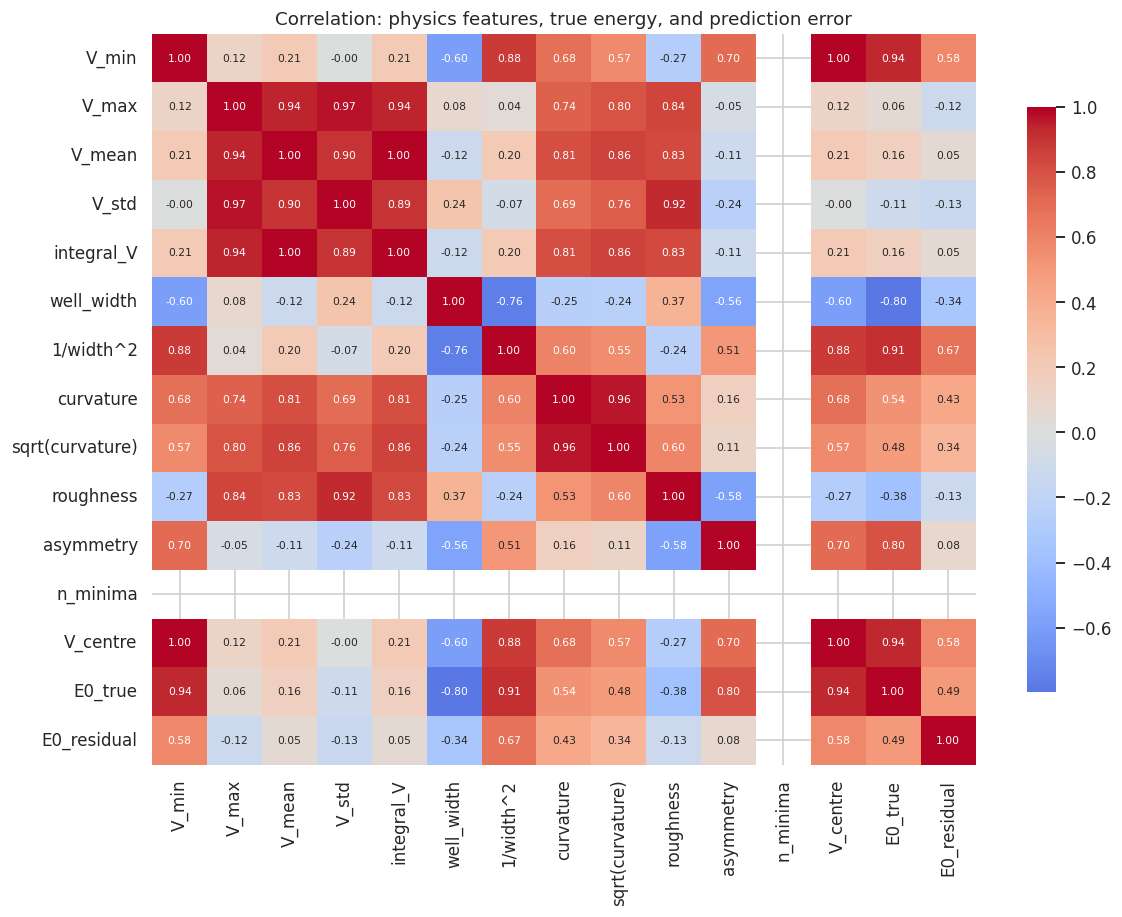

In [ ]:
df_corr = pd.DataFrame(F_test, columns=FEATURE_NAMES)
df_corr["E0_true"]      = Y_test[:, 0]
df_corr["E0_residual"]  = np.abs(residuals[:, 0])

plt.figure(figsize=(11, 8.5))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
plt.title("Correlation: physics features, true energy, and prediction error")
plt.tight_layout(); plt.show()

## 9. Stress test A — out-of-distribution potentials

The original notebook tested a quartic potential and reported ~3% error, presenting this as
evidence of generalisation. Because that model had memorised three potentials, the number
was not meaningful.

Here we run the same test honestly, on three shapes never seen in training:

- **Quartic** $V = \lambda x^4$ — anharmonic, single minimum
- **Anharmonic** $V = \tfrac12 kx^2 + \lambda x^4$ — a mild perturbation of a training family
- **Double well** $V = h\left[(x/b)^2-1\right]^2$ — **two** minima, a shape unlike anything in training

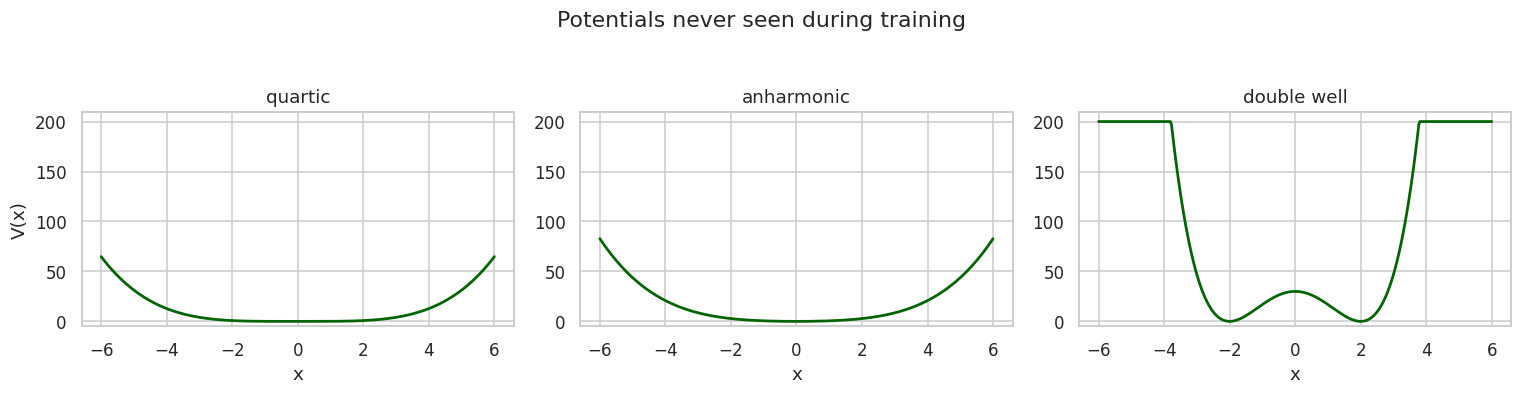

potential,n,exact,ridge/grid,err % (grid),OLS/physics,err % (physics)
quartic,0,0.2461,0.3670,49.14,0.0975,60.38
quartic,1,0.8817,1.0673,21.04,-0.1229,113.94
quartic,2,1.7300,1.7028,1.57,-1.1633,167.24
quartic,3,2.7018,2.2820,15.54,-2.9890,210.63
quartic,4,3.7728,2.8439,24.62,-5.4653,244.86
quartic,5,4.9269,3.4633,29.71,-8.2199,266.84
anharmonic,0,0.5326,0.4679,12.15,0.4680,12.12
anharmonic,1,1.6532,1.3358,19.20,1.1782,28.74
anharmonic,2,2.8734,2.0721,27.89,1.4431,49.78
anharmonic,3,4.1751,2.6900,35.57,1.2862,69.19


In [ ]:
def V_quartic(lam=0.05):        return np.minimum(lam * x_grid**4, V_CEIL)
def V_anharmonic(k=1.0, lam=0.05): return np.minimum(0.5*k*x_grid**2 + lam*x_grid**4, V_CEIL)
def V_double_well(b=2.0, h=30.0):  return np.minimum(h * ((x_grid/b)**2 - 1)**2, V_CEIL)

unseen = {"quartic": V_quartic(), "anharmonic": V_anharmonic(),
          "double well": V_double_well()}

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
for ax, (nm, Vu) in zip(axes, unseen.items()):
    ax.plot(x_grid, Vu, color="darkgreen", lw=1.8)
    ax.set_title(nm); ax.set_xlabel("x"); ax.set_ylim(-5, 210)
axes[0].set_ylabel("V(x)")
plt.suptitle("Potentials never seen during training", y=1.05)
plt.tight_layout(); plt.show()

rows = []
for nm, Vu in unseen.items():
    E_true  = solve_schrodinger(Vu)
    E_ridge = models[best].predict(scaler.transform([Vu]))[0]
    E_phys  = model_phys.predict(scaler_f.transform([physics_features(Vu)]))[0]
    for n in range(N_STATES):
        rows.append([nm, n, E_true[n], E_ridge[n],
                     abs(E_ridge[n]-E_true[n])/abs(E_true[n])*100,
                     E_phys[n], abs(E_phys[n]-E_true[n])/abs(E_true[n])*100])

df_unseen = pd.DataFrame(rows, columns=["potential", "n", "exact", "ridge/grid",
                                        "err % (grid)", "OLS/physics", "err % (physics)"])
display(df_unseen.style.format({"exact": "{:.4f}", "ridge/grid": "{:.4f}",
                                "err % (grid)": "{:.2f}", "OLS/physics": "{:.4f}",
                                "err % (physics)": "{:.2f}"}).hide(axis="index"))

**Read this table carefully — it is the most scientifically interesting result in the
project.** Accuracy degrades sharply outside the training distribution, and the double well
is worst of all.

There is a concrete reason for the double-well catastrophe. Every training potential has its
minimum at exactly $x=0$, so the centre grid column has almost **zero variance**.
`StandardScaler` divides by that near-zero standard deviation, so the double well — which has
a *barrier* at the centre — is mapped to an enormous standardised value far outside anything
the model was fitted on, and the linear extrapolation explodes.

The next section confirms this diagnosis by removing the degeneracy.

## 10. Stress test B — translation invariance

The energy spectrum is invariant under a rigid translation $V(x)\to V(x-x_0)$, but the raw
grid representation is *not*: shifting the well changes every feature. A model fed raw grid
values has no way to know this symmetry exists, whereas our physics features (well width,
curvature, depth) are translation-invariant by construction.

We test this by rebuilding the dataset with randomly centred wells.

In [ ]:
rng_j = np.random.default_rng(SEED + 1)
Xj, Yj, METAj = build_dataset(1500, rng_j, jitter=True)
famj = np.array([m["family"] for m in METAj])

Xj_tr, Xj_te, Yj_tr, Yj_te = train_test_split(Xj, Yj, test_size=0.2,
                                              random_state=SEED, stratify=famj)
sc_j = StandardScaler(); Xj_tr_s = sc_j.fit_transform(Xj_tr); Xj_te_s = sc_j.transform(Xj_te)

Fj_tr = np.array([physics_features(v) for v in Xj_tr])
Fj_te = np.array([physics_features(v) for v in Xj_te])
scf_j = StandardScaler(); Fj_tr_s = scf_j.fit_transform(Fj_tr); Fj_te_s = scf_j.transform(Fj_te)

rows = []
mg = RidgeCV(alphas=np.logspace(-3, 4, 40)).fit(Xj_tr_s, Yj_tr)
Pg = mg.predict(Xj_te_s)
rows.append(["Ridge / raw grid", r2_score(Yj_te, Pg), mean_absolute_error(Yj_te, Pg)])

mf = LinearRegression().fit(Fj_tr_s, Yj_tr)
Pf = mf.predict(Fj_te_s)
rows.append(["OLS / physics features", r2_score(Yj_te, Pf), mean_absolute_error(Yj_te, Pf)])

mr = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1).fit(Fj_tr_s, Yj_tr)
Pr = mr.predict(Fj_te_s)
rows.append(["RandomForest / physics features", r2_score(Yj_te, Pr),
             mean_absolute_error(Yj_te, Pr)])

print("Randomly centred (translated) wells:\n")
display(pd.DataFrame(rows, columns=["model", "R2 (all states)", "MAE"]
                     ).style.format({"R2 (all states)": "{:.4f}",
                                     "MAE": "{:.4f}"}).hide(axis="index"))

Vdw = V_double_well()
E_true_dw = solve_schrodinger(Vdw)
E_dw_grid = mg.predict(sc_j.transform([Vdw]))[0]
E_dw_phys = mf.predict(scf_j.transform([physics_features(Vdw)]))[0]
print("\nDouble well, now that training data is no longer centre-degenerate:")
display(pd.DataFrame({
    "n": range(N_STATES), "exact": E_true_dw,
    "ridge/grid": E_dw_grid,
    "err % (grid)": np.abs(E_dw_grid - E_true_dw)/np.abs(E_true_dw)*100,
    "OLS/physics": E_dw_phys,
    "err % (physics)": np.abs(E_dw_phys - E_true_dw)/np.abs(E_true_dw)*100,
}).style.format({"exact": "{:.4f}", "ridge/grid": "{:.4f}", "err % (grid)": "{:.2f}",
                 "OLS/physics": "{:.4f}", "err % (physics)": "{:.2f}"}).hide(axis="index"))

Randomly centred (translated) wells:



model,R2 (all states),MAE
Ridge / raw grid,0.3438,3.3175
OLS / physics features,0.9822,0.6864
RandomForest / physics features,0.9992,0.0761



Double well, now that training data is no longer centre-degenerate:


n,exact,ridge/grid,err % (grid),OLS/physics,err % (physics)
0,3.8064,0.7515,80.26,3.2528,14.54
1,3.8064,2.2245,41.56,8.7293,129.33
2,11.1353,3.6399,67.31,12.1646,9.24
3,11.1353,5.0055,55.05,13.6093,22.22
4,17.9706,6.3565,64.63,13.2351,26.35
5,17.9722,7.7547,56.85,11.4004,36.57


Two conclusions:

1. The double-well error collapses from astronomical to merely poor once the training
   distribution is no longer centre-degenerate — confirming the zero-variance diagnosis.
2. Under translation the **raw-grid** model degrades badly while the **physics-feature**
   model holds up, because its descriptors respect the symmetry of the problem.

This is a compact demonstration of a central principle of scientific machine learning:
*encode known symmetries in the representation rather than hoping the model discovers them.*

## 11. Exporting results for the LaTeX report

In [ ]:
tex_models = df_feat.to_latex(index=False, float_format="%.5g",
    caption="Model comparison for eigenvalue prediction (natural units, $\\hbar=m=1$).",
    label="tab:model_comparison")
tex_unseen = df_unseen.to_latex(index=False, float_format="%.4f",
    caption="Performance on potentials absent from the training set.",
    label="tab:unseen")

with open("table_model_comparison.tex", "w") as fh: fh.write(tex_models)
with open("table_unseen.tex", "w") as fh: fh.write(tex_unseen)

print(tex_models)
print("\nWritten: table_model_comparison.tex, table_unseen.tex")

\begin{table}
\caption{Model comparison for eigenvalue prediction (natural units, $\hbar=m=1$).}
\label{tab:model_comparison}
\begin{tabular}{lrrrr}
\toprule
model & MAE & RMSE & R2 (all states) & R2 (E0) \\
\midrule
OLS (LinearRegression) & 1.0241 & 2.2608 & 0.92045 & 0.96119 \\
Ridge (alpha=5.88) & 1.0374 & 2.211 & 0.92283 & 0.96057 \\
RandomForest & 0.062437 & 0.25149 & 0.9986 & 0.9978 \\
OLS (physics feats) & 0.58703 & 1.4646 & 0.97251 & 0.99719 \\
Ridge (physics feats) & 0.58891 & 1.4654 & 0.97247 & 0.99715 \\
RandomForest (physics feats) & 0.07882 & 0.35423 & 0.99824 & 0.99952 \\
\bottomrule
\end{tabular}
\end{table}


Written: table_model_comparison.tex, table_unseen.tex


## 12. Conclusions

**On the original result.** The reported $R^2 = 1.0000$ was produced by data leakage: the
generators returned identical arrays, so only three distinct potentials existed and all three
appeared in both train and test splits. A perfect score on memorised data is not a finding.

**On the corrected result.** With genuinely varied potentials on a fixed grid:

- The mapping $V \mapsto \{E_n\}$ is learnable to high accuracy **within the training
  distribution**.
- $R^2$ does not reach $1$, and should not: $E\propto\sqrt{k}$ for the oscillator and
  $E\propto 1/L^2$ for a well are non-linear relations that a model linear in $V$ cannot
  represent exactly. The residual gap *is* the physics.
- Ordinary least squares is inappropriate: the design matrix is severely rank-deficient
  because flat regions of a potential produce identical columns. Ridge regularisation fixes
  this in one line.
- Thirteen physics-motivated features match or beat 400 raw grid points, and supplying
  $1/\text{width}^2$ and $\sqrt{\text{curvature}}$ — the functional forms suggested by the
  analytic solutions — is what makes a *linear* model competitive.
- Generalisation to genuinely new potential shapes is limited, and fails hardest where the
  training distribution is degenerate. Representations that respect the symmetries of the
  problem degrade far more gracefully.

**Suggested extensions.** Add more potential families (Morse, Pöschl–Teller, double wells) so
the training distribution spans a wider region of function space; predict eigen*functions* as
well as eigenvalues; replace hand-built features with a 1-D convolutional network, whose
weight sharing enforces translation invariance automatically; and use $k$-fold
cross-validation rather than a single split for more reliable error bars.